To use this notebook we will be using a branch of `mtpy-v2` that is not released yet.  We will also be using `panel` applications for more interactive plotting.

To create an environment in `conda`:

1. `conda create -n mt python=3.14`
2. `pip install mtpy-v2`
3. `pip install jupyterlab`

To install the beta version of `mtpy-v2`
1. `pip install git+https://github.com/MTgeophysics/mtpy-v2.git@bokeh`
2. `pip install jupyter_bokeh`


# Load in data

Here we will load in a transfer functions from all of SAGE around the Valles Caldera as edi files and save them to a HDF5 file.

In [1]:
from pathlib import Path
from mtpy import MTData, MTCollection

import panel as pn
pn.extension(comms='vscode')

In [ ]:
h5_exists = True
if h5_exists is False:  
    edi_path = Path(r"c:\Users\jpeacock\OneDrive - DOI\SAGE\EDI_Files\renamed")
    md = MTData()
    md.add_station(list(edi_path.glob("*.edi")))
    with MTCollection() as mc:
        mc.open_collection(r"c:\Users\jpeacock\OneDrive - DOI\SAGE\sage_2026.h5")
        mc.from_mt_data(md)
    h5_exists = True
elif h5_exists is True:
    with MTCollection() as mc:
        mc.open_collection(r"c:\Users\jpeacock\OneDrive - DOI\SAGE\sage_2026.h5")
        md = mc.to_mt_data()

# Plot Station Locations

This will plot stations on a basemap.  You can change a few parameters like station symbol and color and the basemap.

In [ ]:
station_plot = md.plot_stations()
station_plot.panel().servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'7574f7f8-0552-4044-adbe-d8b1f1e2f998': {'version…

# Plot MT Response

Here we will plot the MT response for a single station, but you can plot multiple stations in one.

In [6]:
plot_mt_responses = md.plot_mt_responses()
plot_mt_responses.panel().servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'08d5c9b1-6a23-4026-b3df-b5699c446a29': {'version…

# Plot Phase Tensor Maps

In [8]:
plot_pt_map = md.plot_phase_tensor_map()
plot_pt_map.panel().servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'4b92afb7-eef1-42e6-8fb2-f2e36250d993': {'version…

# Plot Geoelectric Strike


In [10]:
plot_strike = md.plot_strike()
plot_strike.panel().servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'b33a35bf-ef36-415c-9939-f561f3ac108e': {'version…

# Extract a Profile

In [ ]:
md.utm_epsg = 32613

In [14]:
profile = md.get_profile(-106.5, 35.96, -106.3, 35.96, 1500)

## plot profile stations

In [15]:
profile_stations = profile.plot_stations()
profile_stations.panel().servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'9a3c3cc0-d1a4-4d1b-aabb-790abddfcf57': {'version…

## Plot Profile Pseudosections

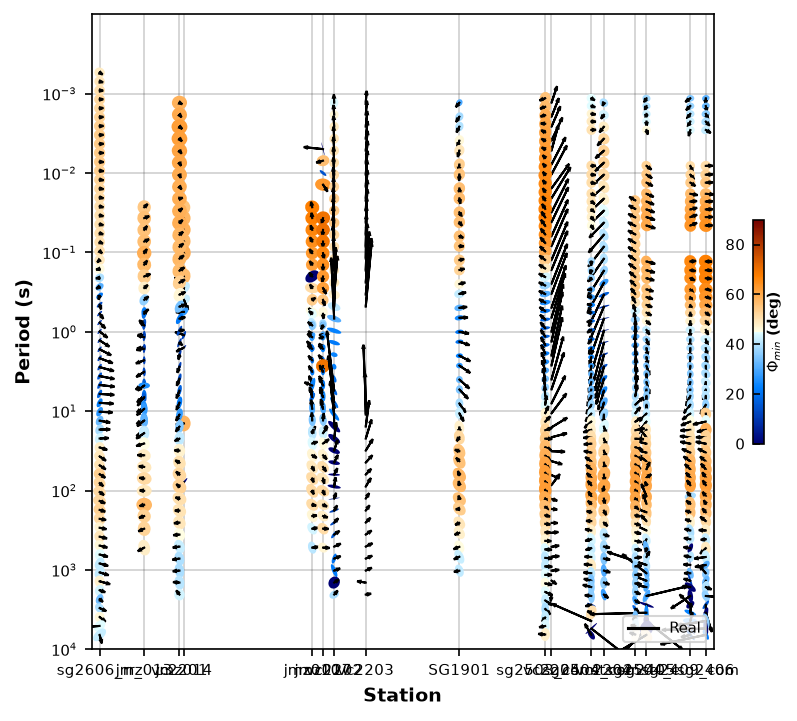

In [19]:
profile_pt_ps = profile.plot_phase_tensor_pseudosection(backend="matplotlib")
profile_pt_ps.x_stretch = 5
profile_pt_ps.plot_tipper = "yr"
profile_pt_ps.plot()


In [20]:
profile_res_ps = profile.plot_resistivity_phase_pseudosections()
profile_res_ps.panel().servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'00744396-2e74-4ac9-9f2b-8e7ef4a4e131': {'version…

# 1D inversion

In [ ]:
from mtpy.imaging.bokeh.panel_simpeg1d_app import SimPEG1DApp

simpeg_app = SimPEG1DApp(md)
simpeg_app.panel().servable()